# Notebook 06: Population Size & Demography

This notebook explores how **population size dynamics** affect the polyploid crossing model:

1. **Logistic growth** — populations grow/shrink toward carrying capacity with demographic stochasticity
2. **Effective population size (Ne)** — the genetic "effective" size is smaller than census size due to SI mate restrictions

These concepts are then applied to the real *Lepidium papilliferum* populations to assess viability and drift risk.

**Prerequisites**: Run `00_load_data.ipynb` first to generate `data/population.pkl`.

In [1]:
import os
import sys
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

sys.path.insert(0, "../src")
from polyploid_utils import *

In [2]:
with open("../data/population.pkl", "rb") as f:
    data = pickle.load(f)

population = data["population"]
pop_populations = data["pop_populations"]
allele_pool_full = data["allele_pool"]
all_alleles = set(range(len(allele_pool_full)))

# Identify major populations (>= 5 individuals)
major_pops = sorted([p for p, inds in pop_populations.items() if len(inds) >= 5])
print(f"Loaded {len(population)} individuals, {len(all_alleles)} alleles")
print(f"Major populations (n>=5): {major_pops}")
for p in major_pops:
    print(f"  Pop {p}: {len(pop_populations[p])} individuals")

Loaded 124 individuals, 94 alleles
Major populations (n>=5): ['25', '27', '67', '76']
  Pop 25: 31 individuals
  Pop 27: 15 individuals
  Pop 67: 22 individuals
  Pop 76: 27 individuals


---
## Part 1: Logistic Growth & Demographic Stochasticity

The current model holds population size constant (`n_offspring = len(population)`). In reality, populations grow toward a carrying capacity $K$ at rate $r$, with random variation:

$$N_{t+1} = N_t + N_t \cdot r \cdot \left(1 - \frac{N_t}{K}\right) + \text{noise}$$

Small populations experience high variance (demographic stochasticity), making allele loss more likely even without selection.

### 1.1 Logistic Growth Trajectories

Visualize how different starting sizes converge to carrying capacity, and how stochastic noise affects small vs. large populations.

/Users/jimbeck/.tmp/ipykernel_58254/396703279.py:45: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/polyploid-model/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


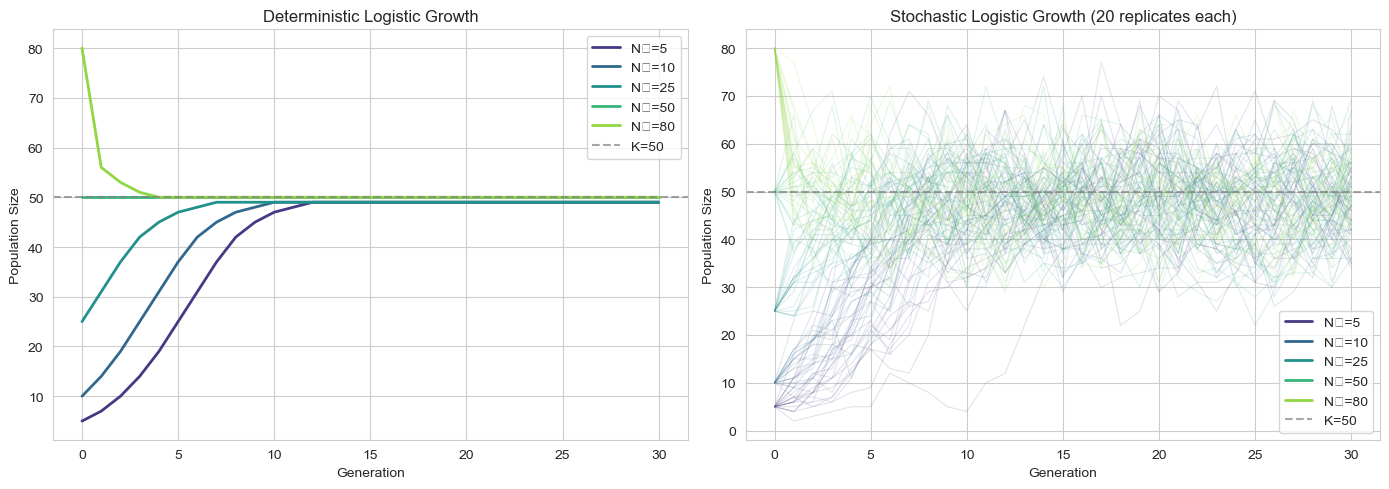

In [3]:
# Demonstrate logistic growth trajectories for different starting sizes
K = 50  # carrying capacity
r = 0.5  # intrinsic growth rate
n_gen = 30
n_replicates = 20

starting_sizes = [5, 10, 25, 50, 80]
colors = sns.color_palette("viridis", len(starting_sizes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: deterministic trajectories
ax = axes[0]
for N0, color in zip(starting_sizes, colors):
    trajectory = [N0]
    N = N0
    for _ in range(n_gen):
        N = logistic_n_offspring(N, K, r, stochastic=False)
        trajectory.append(N)
    ax.plot(trajectory, color=color, label=f"N₀={N0}", linewidth=2)
ax.axhline(K, color="gray", linestyle="--", alpha=0.7, label=f"K={K}")
ax.set_xlabel("Generation")
ax.set_ylabel("Population Size")
ax.set_title("Deterministic Logistic Growth")
ax.legend()

# Right: stochastic trajectories (multiple replicates)
ax = axes[1]
for N0, color in zip(starting_sizes, colors):
    for rep in range(n_replicates):
        trajectory = [N0]
        N = N0
        for _ in range(n_gen):
            N = logistic_n_offspring(N, K, r, stochastic=True)
            trajectory.append(N)
        ax.plot(trajectory, color=color, alpha=0.15, linewidth=0.8)
    # Plot mean label only once
    ax.plot([], [], color=color, label=f"N₀={N0}", linewidth=2)
ax.axhline(K, color="gray", linestyle="--", alpha=0.7, label=f"K={K}")
ax.set_xlabel("Generation")
ax.set_ylabel("Population Size")
ax.set_title(f"Stochastic Logistic Growth ({n_replicates} replicates each)")
ax.legend()

plt.tight_layout()
plt.show()

### 1.2 Demographic Stochasticity: Variance by Population Size

Small populations experience proportionally larger fluctuations. This drives allele loss even without directional selection.

/Users/jimbeck/.tmp/ipykernel_58254/2404355000.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


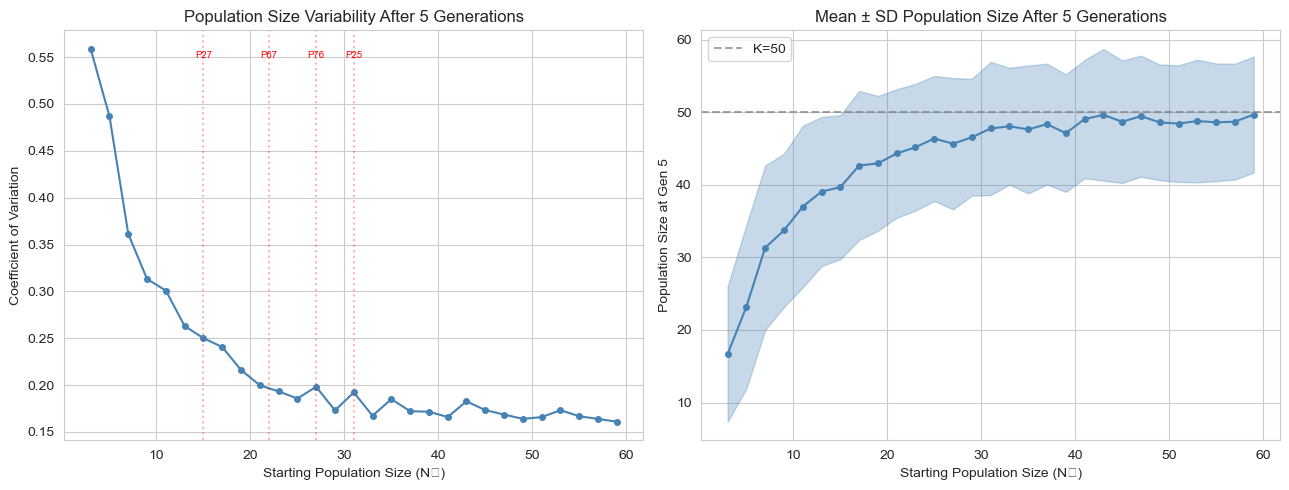

In [4]:
# Measure coefficient of variation in population size at generation 5
K = 50
r = 0.5
test_sizes = list(range(3, 61, 2))
n_replicates = 200
n_gen = 5

cv_data = []
for N0 in test_sizes:
    final_sizes = []
    for _ in range(n_replicates):
        N = N0
        for _ in range(n_gen):
            N = logistic_n_offspring(N, K, r, stochastic=True)
        final_sizes.append(N)
    final_sizes = np.array(final_sizes)
    cv = final_sizes.std() / final_sizes.mean() if final_sizes.mean() > 0 else 0
    cv_data.append({"N0": N0, "CV": cv, "mean": final_sizes.mean(), "std": final_sizes.std()})

cv_df = pd.DataFrame(cv_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(cv_df["N0"], cv_df["CV"], "o-", color="steelblue", markersize=4)
ax.set_xlabel("Starting Population Size (N₀)")
ax.set_ylabel("Coefficient of Variation")
ax.set_title(f"Population Size Variability After {n_gen} Generations")
# Mark real population sizes
for p in major_pops:
    n = len(pop_populations[p])
    if n <= max(test_sizes):
        ax.axvline(n, color="red", alpha=0.3, linestyle=":")
        ax.text(n, ax.get_ylim()[1] * 0.95, f"P{p}", fontsize=7,
                ha="center", color="red")

ax = axes[1]
ax.fill_between(cv_df["N0"], cv_df["mean"] - cv_df["std"],
                cv_df["mean"] + cv_df["std"], alpha=0.3, color="steelblue")
ax.plot(cv_df["N0"], cv_df["mean"], "o-", color="steelblue", markersize=4)
ax.axhline(K, color="gray", linestyle="--", alpha=0.7, label=f"K={K}")
ax.set_xlabel("Starting Population Size (N₀)")
ax.set_ylabel(f"Population Size at Gen {n_gen}")
ax.set_title(f"Mean ± SD Population Size After {n_gen} Generations")
ax.legend()

plt.tight_layout()
plt.show()

### 1.3 Allele Loss Under Demographic Stochasticity

Simulate the actual crossing model with dynamic population size vs. fixed size to compare allele loss rates. Uses a synthetic population for controlled comparison.

In [5]:
# Use Pop 25 (largest major population) as test case
test_pop_id = major_pops[0]
test_pop = list(pop_populations[test_pop_id])
test_alleles = set()
for g in test_pop:
    test_alleles.update(g)
test_alleles = sorted(test_alleles)

N0 = len(test_pop)
K = N0 * 3  # carrying capacity = 3x starting size
r = 0.5
n_gen = 15
n_trials = 10

print(f"Test population: Pop {test_pop_id}, N={N0}, {len(test_alleles)} alleles, K={K}")

results = {"fixed": [], "logistic_det": [], "logistic_stoch": []}

for trial in range(n_trials):
    for mode in results:
        pop = list(test_pop)
        trail = {"pop_size": [len(pop)], "extinct": [0], "endangered": [0],
                 "variance": [], "chi_sq": []}
        d = distance_from_equilibrium(pop, test_alleles)
        trail["variance"].append(d["variance"])
        trail["chi_sq"].append(d["chi_squared"])

        for gen in range(n_gen):
            if mode == "fixed":
                n_off = N0
            elif mode == "logistic_det":
                n_off = logistic_n_offspring(len(pop), K, r, stochastic=False)
            else:
                n_off = logistic_n_offspring(len(pop), K, r, stochastic=True)

            pop = simulate_generation(pop, n_offspring=n_off)
            d = distance_from_equilibrium(pop, test_alleles)
            trail["pop_size"].append(len(pop))
            trail["extinct"].append(d["extinct_alleles"])
            trail["endangered"].append(d["endangered_alleles"])
            trail["variance"].append(d["variance"])
            trail["chi_sq"].append(d["chi_squared"])

        results[mode].append(trail)

print("Simulation complete.")

Test population: Pop 25, N=31, 26 alleles, K=93


Simulation complete.


/Users/jimbeck/.tmp/ipykernel_58254/2733193573.py:26: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


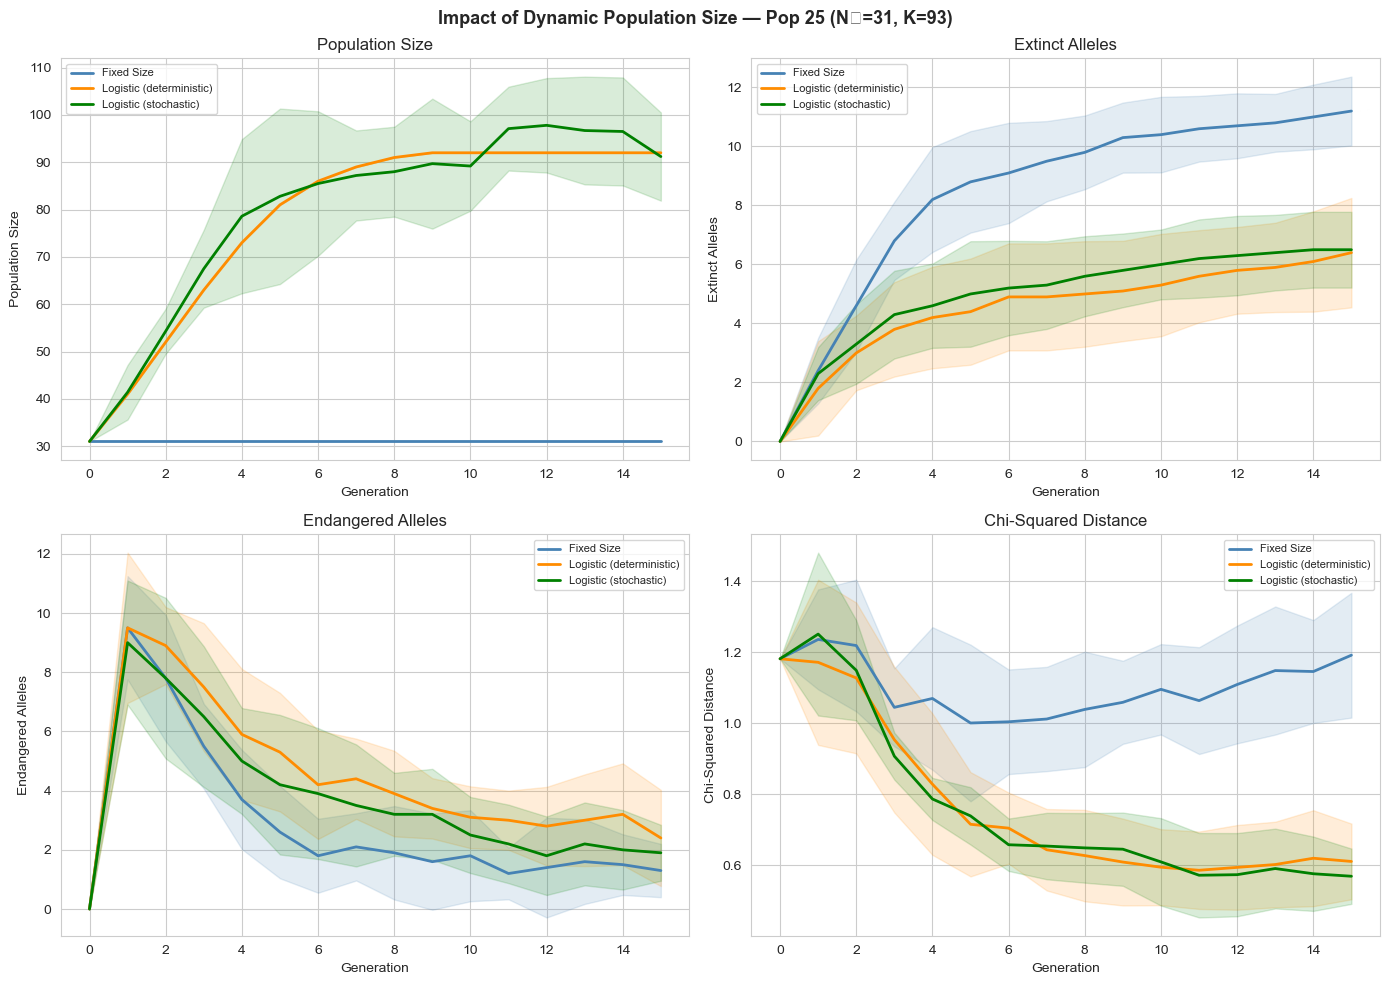

In [6]:
mode_labels = {"fixed": "Fixed Size", "logistic_det": "Logistic (deterministic)",
               "logistic_stoch": "Logistic (stochastic)"}
mode_colors = {"fixed": "steelblue", "logistic_det": "darkorange",
               "logistic_stoch": "green"}
gens = np.arange(n_gen + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [("pop_size", "Population Size"), ("extinct", "Extinct Alleles"),
           ("endangered", "Endangered Alleles"), ("chi_sq", "Chi-Squared Distance")]

for ax, (key, label) in zip(axes.flat, metrics):
    for mode in results:
        vals = np.array([t[key] for t in results[mode]])
        mean = vals.mean(axis=0)
        std = vals.std(axis=0)
        ax.plot(gens, mean, color=mode_colors[mode], label=mode_labels[mode], linewidth=2)
        ax.fill_between(gens, mean - std, mean + std, color=mode_colors[mode], alpha=0.15)
    ax.set_xlabel("Generation")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle(f"Impact of Dynamic Population Size — Pop {test_pop_id} (N₀={N0}, K={K})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 2: Effective Population Size (Ne)

Census size $N$ overstates genetic diversity because SI restricts who can mate with whom. **Effective population size** $N_e$ captures the "genetic" size — the number of individuals in an ideal population that would experience the same rate of genetic drift.

Key factors reducing $N_e$ below $N$:
- SI mate restrictions (not everyone can cross with everyone)
- Variance in reproductive success
- Fluctuating population size (harmonic mean dominates)

### 2.1 Ne for Each Real Population

Compute Ne from the SI compatibility structure for each major population.

In [7]:
ne_results = []

for pop_id in major_pops:
    pop = pop_populations[pop_id]
    pop_alleles = set()
    for g in pop:
        pop_alleles.update(g)

    ne_info = effective_population_size(pop, pop_alleles)
    ne_results.append({
        "Pop": pop_id,
        "N (census)": ne_info["N"],
        "Ne": round(ne_info["Ne"], 1),
        "Ne/N": round(ne_info["ratio"], 3),
        "Breeders": ne_info["n_breeders"],
        "Mean Compat.": round(ne_info["mean_compatibility"], 3),
        "Compatible Pairs": ne_info["total_compatible_pairs"],
    })

ne_df = pd.DataFrame(ne_results)
print("Effective Population Size by Population\n")
print(ne_df.to_string(index=False))

# Flag populations below MVP thresholds
print("\n--- Viability Assessment ---")
for _, row in ne_df.iterrows():
    ne = row["Ne"]
    status = "CRITICAL" if ne < 10 else "AT RISK" if ne < 50 else "OK"
    print(f"  Pop {row['Pop']:>3}: Ne={ne:5.1f}  [{status}]")

Effective Population Size by Population

Pop  N (census)   Ne  Ne/N  Breeders  Mean Compat.  Compatible Pairs
 25          31 28.0 0.902        31         0.902               871
 27          15 14.6 0.973        15         0.973               206
 67          22 20.2 0.916        22         0.916               448
 76          27 23.8 0.880        27         0.880               669

--- Viability Assessment ---
  Pop  25: Ne= 28.0  [AT RISK]
  Pop  27: Ne= 14.6  [AT RISK]
  Pop  67: Ne= 20.2  [AT RISK]
  Pop  76: Ne= 23.8  [AT RISK]


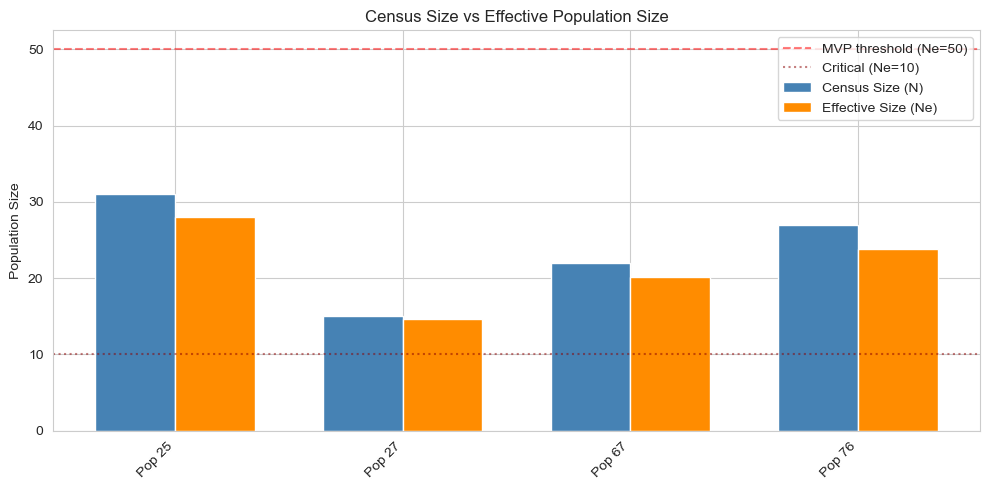

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(ne_df))
width = 0.35
ax.bar(x - width/2, ne_df["N (census)"], width, label="Census Size (N)", color="steelblue")
ax.bar(x + width/2, ne_df["Ne"], width, label="Effective Size (Ne)", color="darkorange")

ax.axhline(50, color="red", linestyle="--", alpha=0.5, label="MVP threshold (Ne=50)")
ax.axhline(10, color="darkred", linestyle=":", alpha=0.5, label="Critical (Ne=10)")

ax.set_xticks(x)
ax.set_xticklabels([f"Pop {p}" for p in ne_df["Pop"]], rotation=45, ha="right")
ax.set_ylabel("Population Size")
ax.set_title("Census Size vs Effective Population Size")
ax.legend()

plt.tight_layout()
plt.show()

### 2.2 Ne Over Generations (Harmonic Mean)

Track Ne across a multi-generation simulation. The harmonic mean of Ne across generations reflects the long-term genetic drift rate — bottleneck generations dominate.

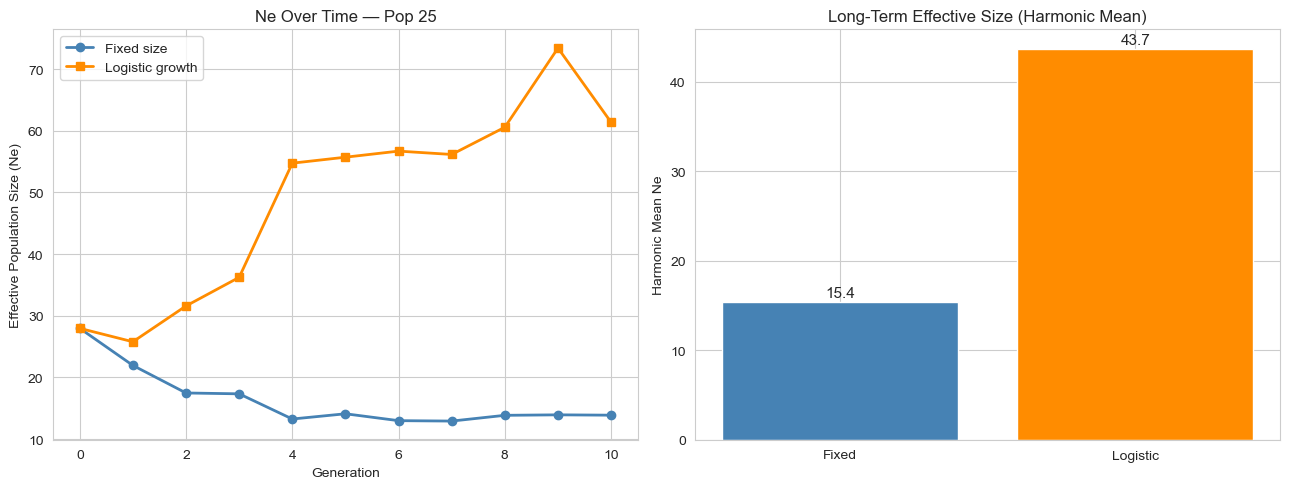

Harmonic mean Ne — Fixed: 15.4, Logistic: 43.7


In [9]:
# Track Ne across generations for the test population under different regimes
n_gen = 10
K = len(test_pop) * 3

ne_tracks = {"fixed": [], "logistic": []}

for mode in ne_tracks:
    pop = list(test_pop)
    ne_series = []

    for gen in range(n_gen + 1):
        pop_alleles = set()
        for g in pop:
            pop_alleles.update(g)
        ne_info = effective_population_size(pop, pop_alleles)
        ne_series.append(ne_info["Ne"])

        if gen < n_gen:
            if mode == "fixed":
                n_off = len(test_pop)
            else:
                n_off = logistic_n_offspring(len(pop), K, r=0.5, stochastic=True)
            pop = simulate_generation(pop, n_offspring=n_off)

    ne_tracks[mode] = ne_series

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(ne_tracks["fixed"], "o-", color="steelblue", label="Fixed size", linewidth=2)
ax.plot(ne_tracks["logistic"], "s-", color="darkorange", label="Logistic growth", linewidth=2)
ax.set_xlabel("Generation")
ax.set_ylabel("Effective Population Size (Ne)")
ax.set_title(f"Ne Over Time — Pop {test_pop_id}")
ax.legend()

ax = axes[1]
hm_fixed = ne_harmonic_mean(ne_tracks["fixed"])
hm_logistic = ne_harmonic_mean(ne_tracks["logistic"])
bars = ax.bar(["Fixed", "Logistic"], [hm_fixed, hm_logistic],
              color=["steelblue", "darkorange"])
ax.set_ylabel("Harmonic Mean Ne")
ax.set_title("Long-Term Effective Size (Harmonic Mean)")
for bar, val in zip(bars, [hm_fixed, hm_logistic]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print(f"Harmonic mean Ne — Fixed: {hm_fixed:.1f}, Logistic: {hm_logistic:.1f}")

---
## Summary

| Concept | Key Finding |
|---------|-------------|
| **Logistic growth** | Small populations grow toward K but with high variance; stochastic crashes increase allele loss risk |
| **Demographic stochasticity** | Populations < 10 experience dramatic size fluctuations; larger populations are buffered |
| **Effective size (Ne)** | SI compatibility reduces Ne well below census N; Ne/N ratio depends on allele diversity |
| **Harmonic mean Ne** | Bottleneck generations dominate long-term drift; dynamic populations have lower harmonic Ne |
| **MVP thresholds** | Most individual populations fall below Ne=50; species-wide management is critical |